HOUSE PRICE PREDICTION

TASK-01 DATA LOADING AND EXPLORATION

In [1]:
import pandas as pd

In [4]:
df=pd.read_csv("data/Housing.csv")

In [5]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [7]:
df.shape

(545, 13)

In [10]:
target_variable="price"

In [12]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

TASK=02 DATA CLEANING

Observation: There are no missing values in the dataset

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df=df.drop_duplicates()

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [20]:
df = pd.get_dummies(df, drop_first=True)

In [23]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

Observation: All the columns are realted to house price and there's nothing to remove

TASK-03 MODEL BUILDING


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [27]:
X = df.drop("price", axis=1)
y = df["price"]

In [28]:
print(X.shape)
print(y.shape)

(545, 13)
(545,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(436, 13)
(109, 13)


In [32]:
lr = LinearRegression()

In [33]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
pred_lr = lr.predict(X_test)

In [35]:
pred_lr[:5]

array([5164653.90033967, 7224722.29802167, 3109863.24240338,
       4612075.32722559, 3294646.25725955])

In [36]:
print("Actual:")
print(y_test.iloc[:5])

print("\nPredicted:")
print(pred_lr[:5])

Actual:
316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
Name: price, dtype: int64

Predicted:
[5164653.90033967 7224722.29802167 3109863.24240338 4612075.32722559
 3294646.25725955]


In [37]:
mae = mean_absolute_error(y_test, pred_lr)

rmse = mean_squared_error(y_test, pred_lr) ** 0.5

r2 = r2_score(y_test, pred_lr)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 970043.4039201635
RMSE: 1324506.9600914384
R2 Score: 0.6529242642153186


LINEAR REGRESSION RESULTS

MAE: 970,043

RMSE: 1,324,507

R² Score: 0.653

The Linear Regression model achieved an R² score of 65.3%, indicating that it explains a significant portion of the variation in house prices. The average prediction error was approximately ₹9.7 lakh. While the model performs reasonably well, there is still room for improvement using more advanced algorithms.

In [38]:
from sklearn.ensemble import RandomForestRegressor

In [43]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [44]:
mae_rf = mean_absolute_error(y_test, pred_rf)

rmse_rf = mean_squared_error(y_test, pred_rf) ** 0.5

r2_rf = r2_score(y_test, pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


Observation: Although Random Forest is often considered a more powerful algorithm, Linear Regression achieved a higher R² score (0.653) than Random Forest (0.618) on this dataset. Therefore, Linear Regression was selected as the better-performing model for this project.

TASK-04 Visualization

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

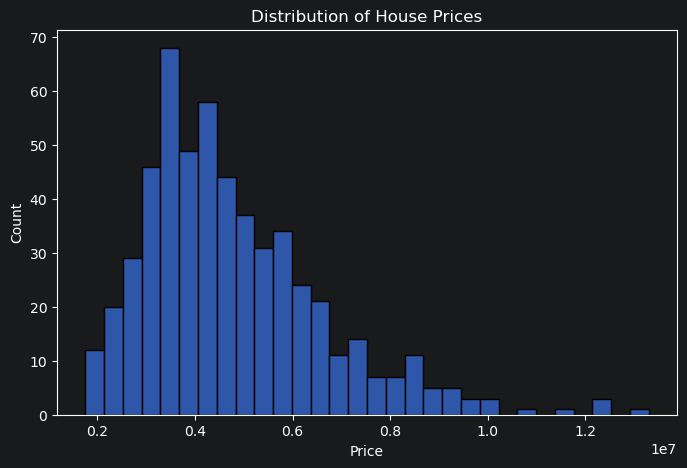

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.savefig("charts/house_price_distribution.png")

plt.show()

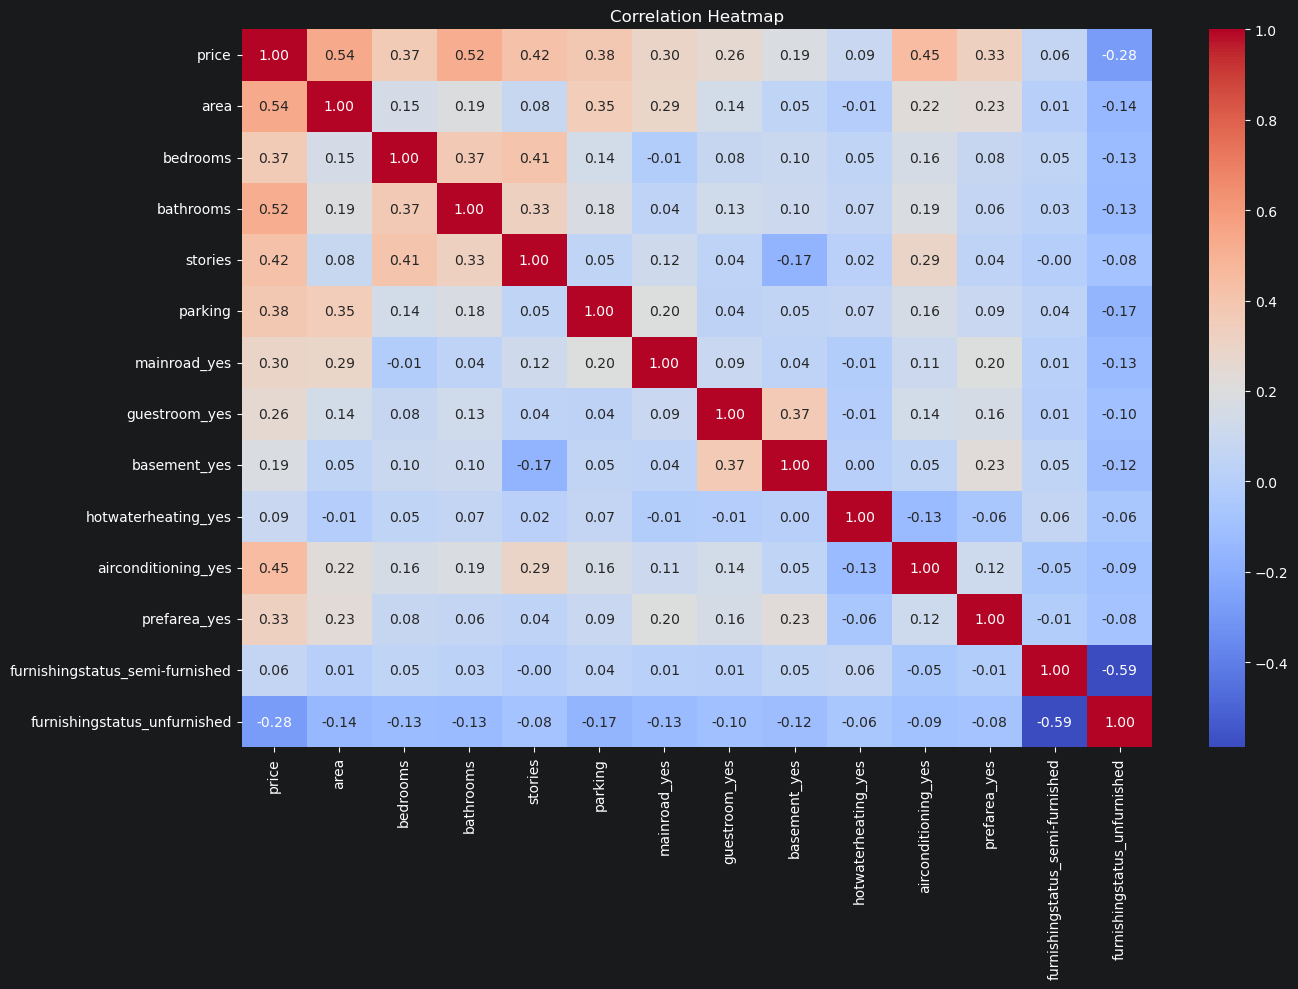

In [51]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("Charts/correlation_heatmap.png")

plt.show()

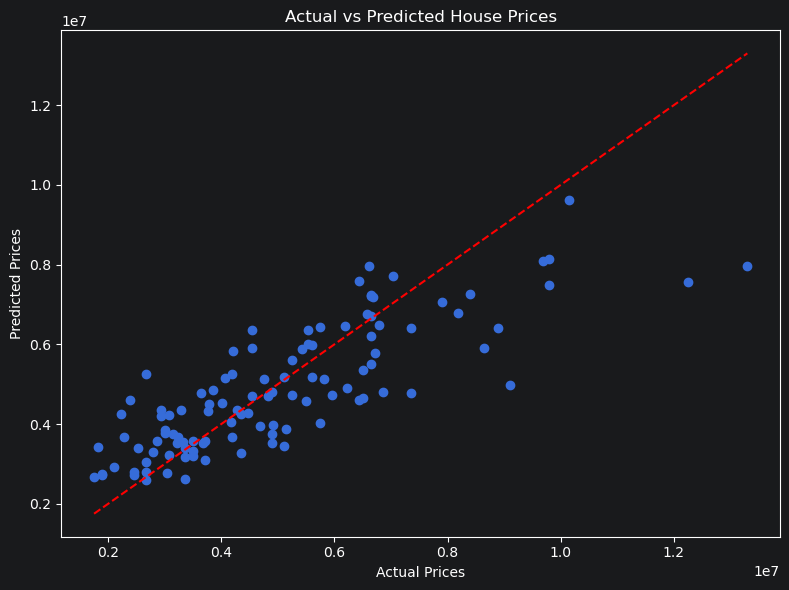

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_lr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.tight_layout()

plt.savefig("Charts/actual_vs_predicted.png")

plt.show()

TASK-05 INSIGHTS AND SUMMARY



The analysis revealed that area, bathrooms, stories, and housing amenities were the most influential factors affecting house prices. The Linear Regression model achieved an R² score of 0.653, indicating reasonable predictive performance. On average, the model's predictions differed from actual prices by about ₹9.7 lakh. A surprising finding was that Linear Regression outperformed Random Forest on this dataset. The housing prices were found to be right-skewed, with only a few highly expensive properties. Based on these results, real estate businesses should emphasize property size and premium amenities when pricing and marketing homes.
